In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('/content/df.csv')

In [8]:
print(df.shape)

(11789, 27)


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [10]:
print(df.describe())

                age  monthly_income  daily_internet_hours  \
count  11789.000000    11789.000000          11789.000000   
mean      48.729409   131704.282382              6.011367   
std       17.899445    68120.726684              1.976811   
min       18.000000    15005.000000              1.000000   
25%       33.000000    72450.000000              4.600000   
50%       49.000000   131916.000000              6.000000   
75%       64.000000   190505.000000              7.400000   
max       79.000000   249989.000000             12.000000   

       smartphone_usage_years  social_media_hours  online_payment_trust_score  \
count            11789.000000        11789.000000                11789.000000   
mean                 7.597930            2.514471                    5.498770   
std                  4.011628            1.263047                    2.880366   
min                  1.000000            0.000000                    1.000000   
25%                  4.000000            1.60

In [11]:
print(df.isnull().sum())

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
total_spending                 0
customer_segment               0
dtype: int64


In [12]:
print(df.isnull().sum())

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
total_spending                 0
customer_segment               0
dtype: int64


In [13]:

df['total_spend'] = df['avg_online_spend'] + df['avg_store_spend']
df['online_spend_ratio'] = df['avg_online_spend'] / df['total_spend']
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,50,65,100],
                         labels=['GenZ','Millennial','GenX','Boomer','Silent'])
df['income_group'] = pd.qcut(df['monthly_income'], q=5, labels=['Low','Lower-Mid','Middle','Upper-Mid','High'])

In [14]:
df['tech_adoption_score'] = (df['tech_savvy_score'] + df['online_payment_trust_score'] +
                            df['daily_internet_hours']*2 + df['social_media_hours']) / 5

In [15]:
print(df.head())
df.to_csv('df_consumer_cleaned.csv', index=False)

   age  monthly_income  daily_internet_hours  smartphone_usage_years  \
0   56          221111                   6.5                      12   
1   69           96029                   8.2                      13   
2   46           19055                   6.4                       4   
3   32           53170                   6.4                      11   
4   60          244016                   6.0                       5   

   social_media_hours  online_payment_trust_score  tech_savvy_score  \
0                 0.7                           1                 6   
1                 2.7                           6                 9   
2                 2.1                          10                 8   
3                 0.7                           2                10   
4                 0.7                           2                 5   

   monthly_online_orders  monthly_store_visits  avg_online_spend  ...  gender  \
0                     16                    16             

In [16]:
from scipy import stats
import statsmodels.api as sm

# Group comparisons
store = df[df['shopping_preference'] == 'Store']
online = df[df['shopping_preference'] == 'Online']

In [17]:
print("Tech Savvy - Store vs Online:")
print(stats.ttest_ind(store['tech_savvy_score'], online['tech_savvy_score']))

Tech Savvy - Store vs Online:
TtestResult(statistic=np.float64(-13.365177182476746), pvalue=np.float64(1.943768312469439e-40), df=np.float64(11418.0))


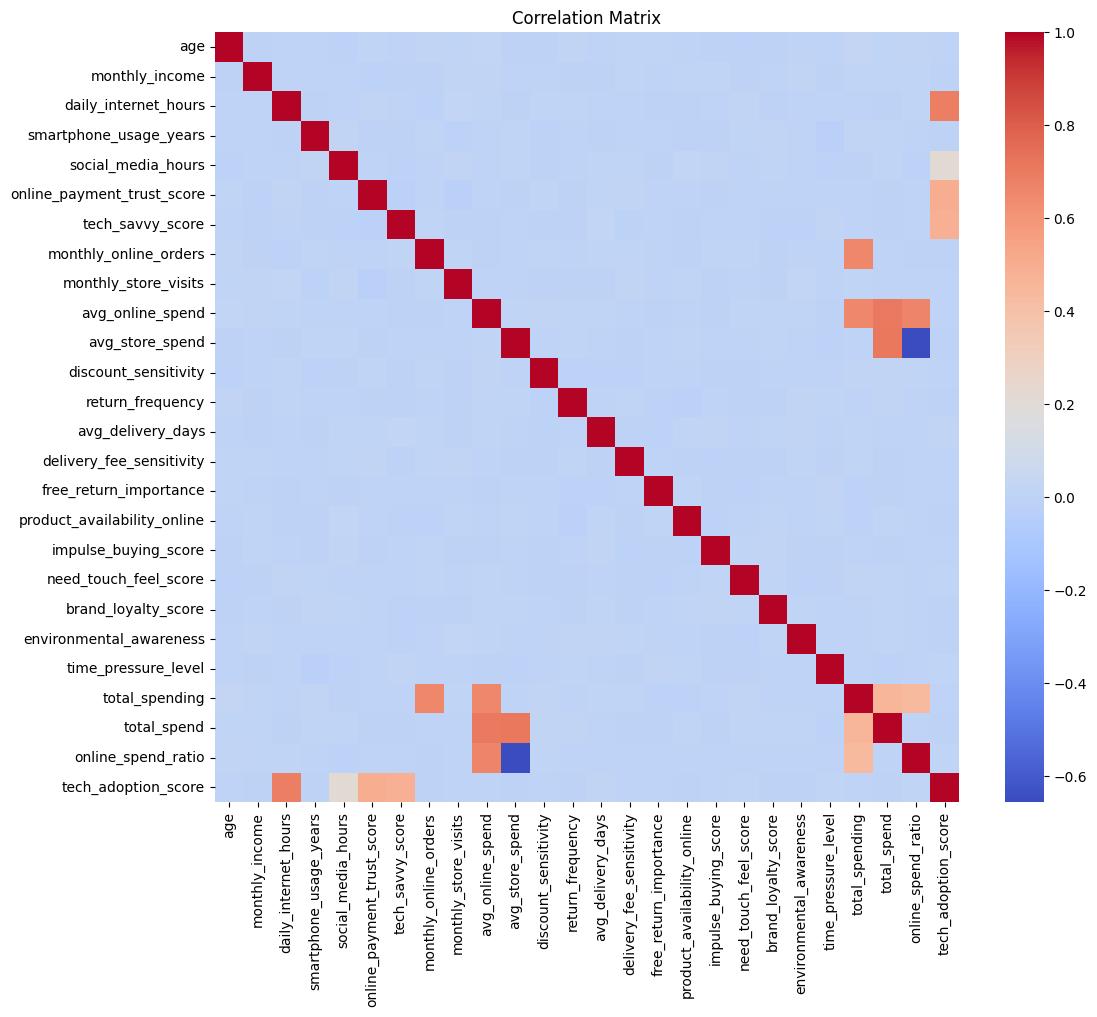

In [18]:
# Correlation Matrix
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [19]:
# Simple Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ['monthly_income', 'tech_adoption_score', 'need_touch_feel_score',
            'discount_sensitivity', 'brand_loyalty_score']

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=4, random_state=42)
df['customer_segment'] = kmeans.fit_predict(X)

df['customer_segment'].value_counts()

,count
customer_segment,
3,3022
2,2953
1,2936
0,2878
